In [57]:
import torch
import pytorch_lightning as pl
from src.regression.models.pl_module import WindNetPL
from src.regression.datamodule import WindDataModule
from omegaconf import DictConfig, OmegaConf
from src.data_assemble.assemble_eval import load_dataset, load_target
import matplotlib.pyplot as plt
import numpy as np
import polars
import seaborn as sns
import pandas as pd 

cfg = OmegaConf.load('configs/test_configs/eval_world_reg.yaml')

In [5]:
target_df = load_target(cfg).to_pandas()
var_data, time_coords, lat_coords, lon_coords = load_dataset(cfg, time_slices = 100000)

In [75]:
meteostation_data = target_df.iloc[0]['y']
meteostation_lat, meteostation_lon = target_df.iloc[0]['station_name']
sim_data_max = var_data[0, :, meteostation_lat, meteostation_lon]
sim_data = var_data[1, :, meteostation_lat, meteostation_lon]

index = min(len(meteostation_data), len(sim_data_max))
plot_df = pd.DataFrame({'wind meteostation': meteostation_data[:index],
                        'max_wind simulation ': sim_data_max[:index],
                        'wind simulation ': sim_data[:index]}, index=time_coords[:index])

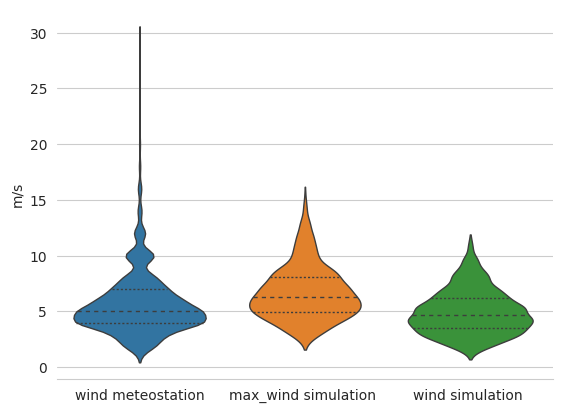

In [78]:
sns.set_style("whitegrid")
ax = sns.violinplot(data=plot_df, labely="wind speed m/s" , bw=.2, cut=1, linewidth=1, inner='quartile')
ax.set(ylabel='m/s')
sns.despine(left=True)
plt.show()

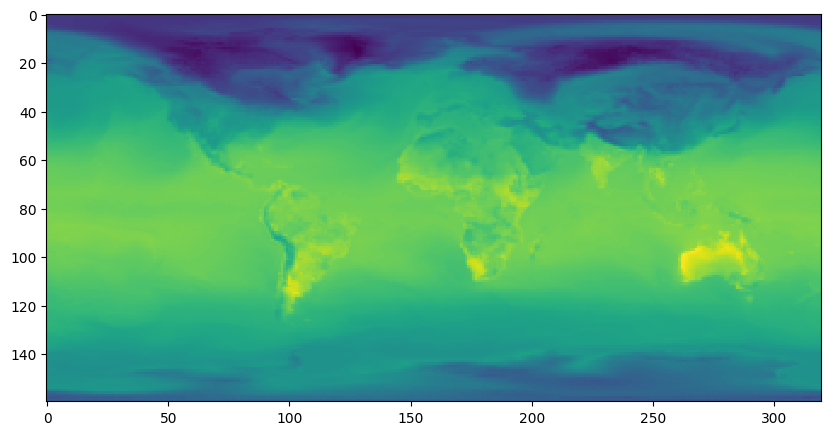

In [34]:
plt.figure(figsize=(10,10))
plt.imshow(np.flipud(var_data[4, 0]), interpolation='nearest')
plt.show()